In [13]:
import pickle
from pathlib import Path
import numpy as np
from tqdm import tqdm
import librosa
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import load_model
from tensorflow.keras import layers, models, callbacks, losses
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [14]:
def create_melspectrogram(segmented_dir, n_mels=128):
    segmented_dir = Path(segmented_dir)
    X = []
    y = []
    labels = [f.name for f in segmented_dir.iterdir() if f.is_dir()]

    for label in tqdm(labels):
        for audio in (segmented_dir / label).iterdir():
            if audio.suffix == '.wav':
                signal, sr = librosa.load(audio, sr=None)
                melspectrogram = librosa.feature.melspectrogram(y=signal, 
                                                                sr=sr, 
                                                                n_mels=n_mels, 
                                                                fmax=sr/2)
                melspectrogram_db = librosa.power_to_db(melspectrogram, ref=np.max)
                X.append(melspectrogram_db)
                y.append(label)
            
    X = np.array(X)
    X = np.expand_dims(X, axis=-1)

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)

    return X, np.array(y), label_encoder

Import data for model

In [15]:
X, y, label_encoder = create_melspectrogram('data/IRMAS_segmented')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=1)

100%|██████████| 11/11 [01:45<00:00,  9.62s/it]


Plot mel spectrogram

In [16]:
def plot_melspectrogram(X, i=0, save_path=None):
    melspectrogram_sample = X[i, :, :, 0]
    librosa.display.specshow(melspectrogram_sample, x_axis='time', y_axis='mel', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('Mel Spectrogram')
    plt.xlabel('Time Frames')
    plt.ylabel('Mel Frequency Bands')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

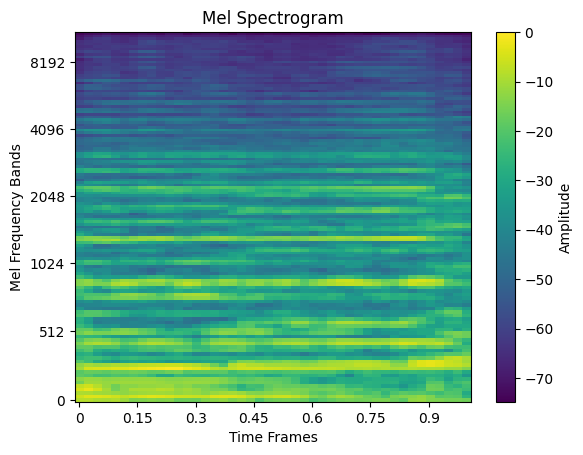

In [17]:
plot_melspectrogram(X)

CNN model

In [18]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

cnn = models.Sequential([
    layers.Input(shape=(X.shape[1], X.shape[2], 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.3),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.4),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(np.unique(y)), activation='softmax')
])

cnn.compile(optimizer='adam',
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'])

cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 44, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 44, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 6, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 6, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 6, 256)     │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 6, 256)     │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,923 (1.55 MB)

 Trainable params: 405,963 (1.55 MB)

 Non-trainable params: 960 (3.75 KB)

Train CNN

In [19]:
# with open('models/melspectrogram_label_encoder.pkl', 'wb') as f:
#     pickle.dump(label_encoder, f)

In [20]:
# early_stopping = callbacks.EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)

# history = cnn.fit(
#     X_train, y_train,
#     epochs=100,
#     validation_data=(X_val, y_val),
#     callbacks=[early_stopping],
#     class_weight=class_weights_dict
# )

# with open('histories/IRMAS_cnn_melspectrogram_history.pkl', 'wb') as f:
#     pickle.dump(history.history, f)

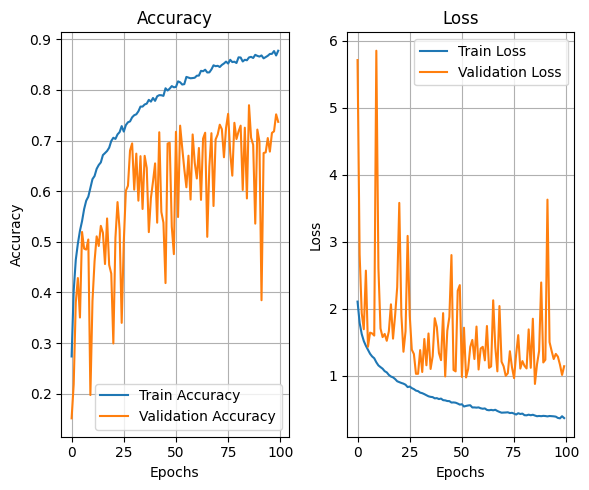

In [21]:
with open('histories/IRMAS_cnn_melspectrogram_history.pkl', 'rb') as f:
    history = pickle.load(f)
    
plt.figure(figsize=(6, 5))

plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig('images/IRMAS_cnn_melspectrogram_training_curves.png')
plt.show()

In [22]:
# Load CNN
cnn = load_model('models/IRMAS_cnn_melspectrogram_model.keras')

c:\Users\grzes\anaconda3\envs\audio\lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 22 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Evaluate CNN

In [23]:
with open('models/melspectrogram_label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
    
y_pred = cnn.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test)

accuracy = accuracy_score(y_test_labels, y_pred_labels)
class_report = classification_report(y_test_labels, y_pred_labels)

print('Accuracy:', accuracy)
print('\nClassification Report:\n', class_report)

output_file = 'evaluations/IRMAS_cnn_melspectrogram_evaluation.txt'

with open(output_file, 'w') as file:
    file.write(f'Accuracy: {accuracy}\n')
    file.write('\nClassification Report:\n')
    file.write(class_report)

# best .71

126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Accuracy: 0.7631121053939846

Classification Report:
               precision    recall  f1-score   support

         cel       0.65      0.86      0.74       233
         cla       0.83      0.70      0.76       303
         flu       0.78      0.63      0.69       270
         gac       0.79      0.83      0.81       382
         gel       0.68      0.71      0.69       456
         org       0.81      0.91      0.85       409
         pia       0.73      0.89      0.80       433
         sax       0.76      0.55      0.64       376
         tru       0.83      0.82      0.82       346
         vio       0.68      0.61      0.64       348
         voi       0.87      0.83      0.85       467

    accuracy                           0.76      4023
   macro avg       0.76      0.76      0.76      4023
weighted avg       0.77      0.76      0.76      4023



Save CNN

In [24]:
# cnn.save('models/IRMAS_cnn_melspectrogram_model.keras', include_optimizer=False)